In [13]:
import scipy.signal
import matplotlib.pyplot as plt
import numpy as np

In [14]:
def generate_m_seq(taps):
    return scipy.signal.max_len_seq(nbits=10, taps=taps, state=[1,0,0,0,0,0,0,1,1,0])[0]


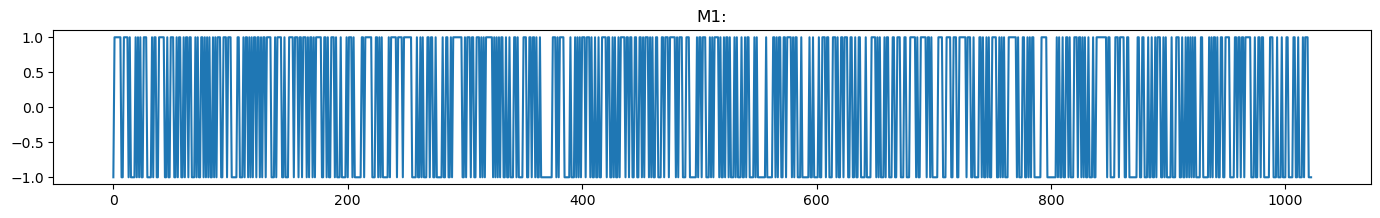

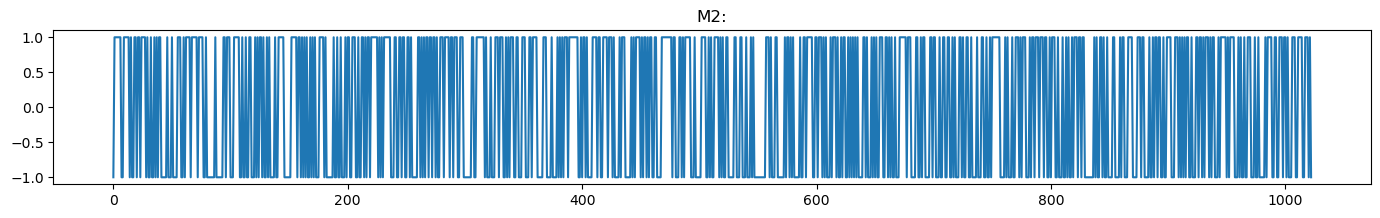

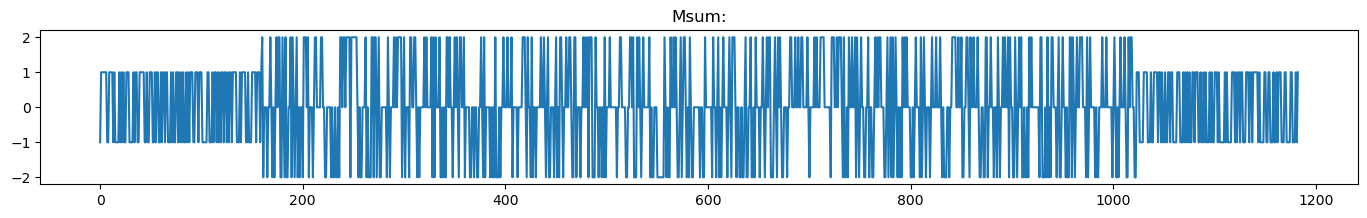

In [15]:
M1 = generate_m_seq([10,7,6,5,2,1,0]).astype(int)
for i in range(len(M1)): M1[i] = -2*M1[i]+1
M2 = generate_m_seq([10,7,6,5,4,1,0]).astype(int)
for i in range(len(M2)): M2[i] = -2*M2[i]+1

plt.figure(figsize=(17, 2))
plt.title('M1:')
plt.plot(M1)
plt.show()
plt.figure(figsize=(17, 2))
plt.title('M2:')
plt.plot(M2)
plt.show()

Msum = []
summarizing_shift = 160
for i in range(len(M1) + summarizing_shift):
    if i < summarizing_shift:
        Msum.append(M1[i])
    elif i < len(M1):
        Msum.append(M1[i] - M2[i-summarizing_shift])
    else:
        Msum.append(-M2[i-summarizing_shift])

plt.figure(figsize=(17, 2))
plt.title('Msum:')
plt.plot(Msum)
plt.show()

C:\Users\8230778\AppData\Local\Temp\ipykernel_10532\1526337099.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


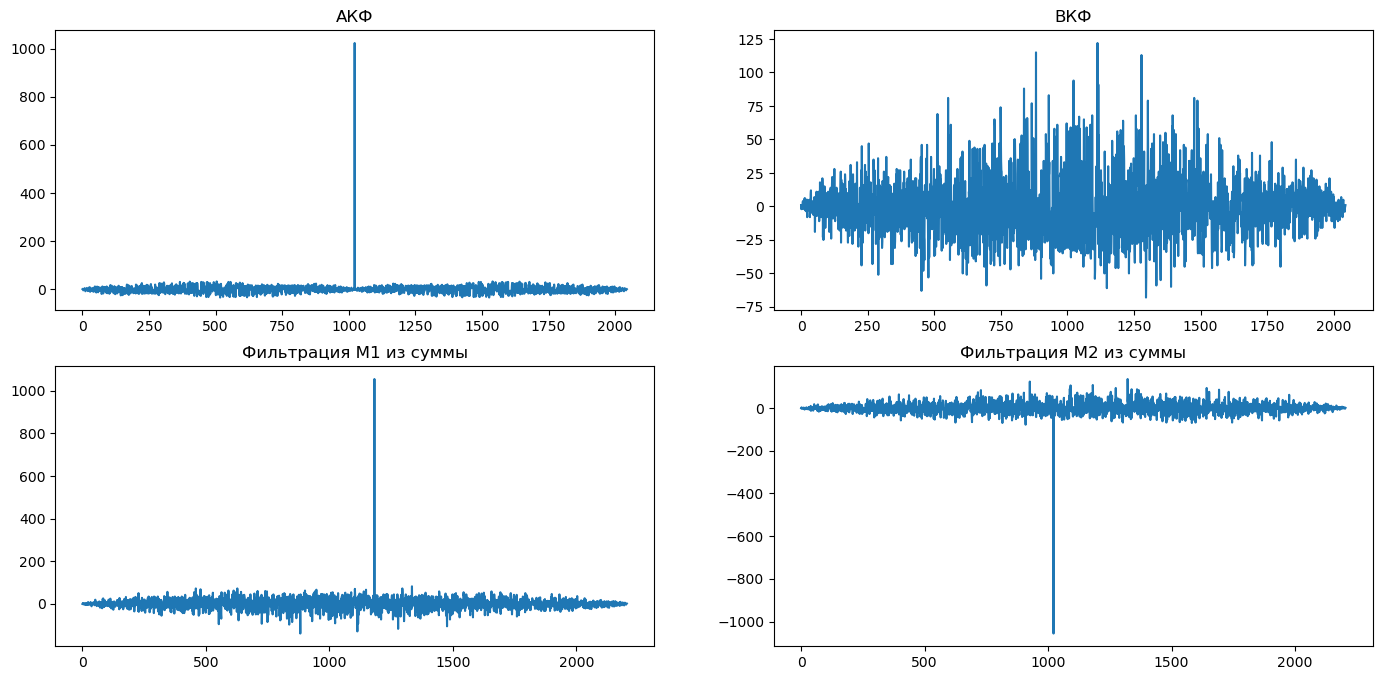

In [16]:
# (3) Построить АКФ для М1, где М1 - и сигнал, и опорная функция

def generate_shifted_array(arr, shift):
    shift %= len(arr)
    o = []
    for i in range(len(arr)):
        idx = i + shift
        if (idx >= len(arr)): idx -= len(arr)
        o.append(arr[idx])
    return o

# print(list(M1))
akf = np.correlate(M1, M1, mode='full')
vkf = np.correlate(M1, M2, mode='full')
m1_filt = np.correlate(M1, Msum, mode='full')
m2_filt = np.correlate(M2, Msum, mode='full')

fig, axes = plt.subplots(2, 2, figsize=(17, 8))
axes[0,0].plot(akf)
axes[0,0].set_title('АКФ')
axes[0,1].plot(vkf)
axes[0,1].set_title('ВКФ')
axes[1,0].plot(m1_filt)
axes[1,0].set_title('Фильтрация М1 из суммы')
axes[1,1].plot(m2_filt)
axes[1,1].set_title('Фильтрация М2 из суммы')
fig.show()

Reduce noise 15 >= 7.5
Increase noise 7.5 >= 11.25
Reduce noise 11.25 >= 9.375
Reduce noise 9.375 >= 8.4375
Reduce noise 8.4375 >= 7.96875
Increase noise 7.96875 >= 8.203125
8.203125


C:\Users\8230778\AppData\Local\Temp\ipykernel_10532\959698995.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


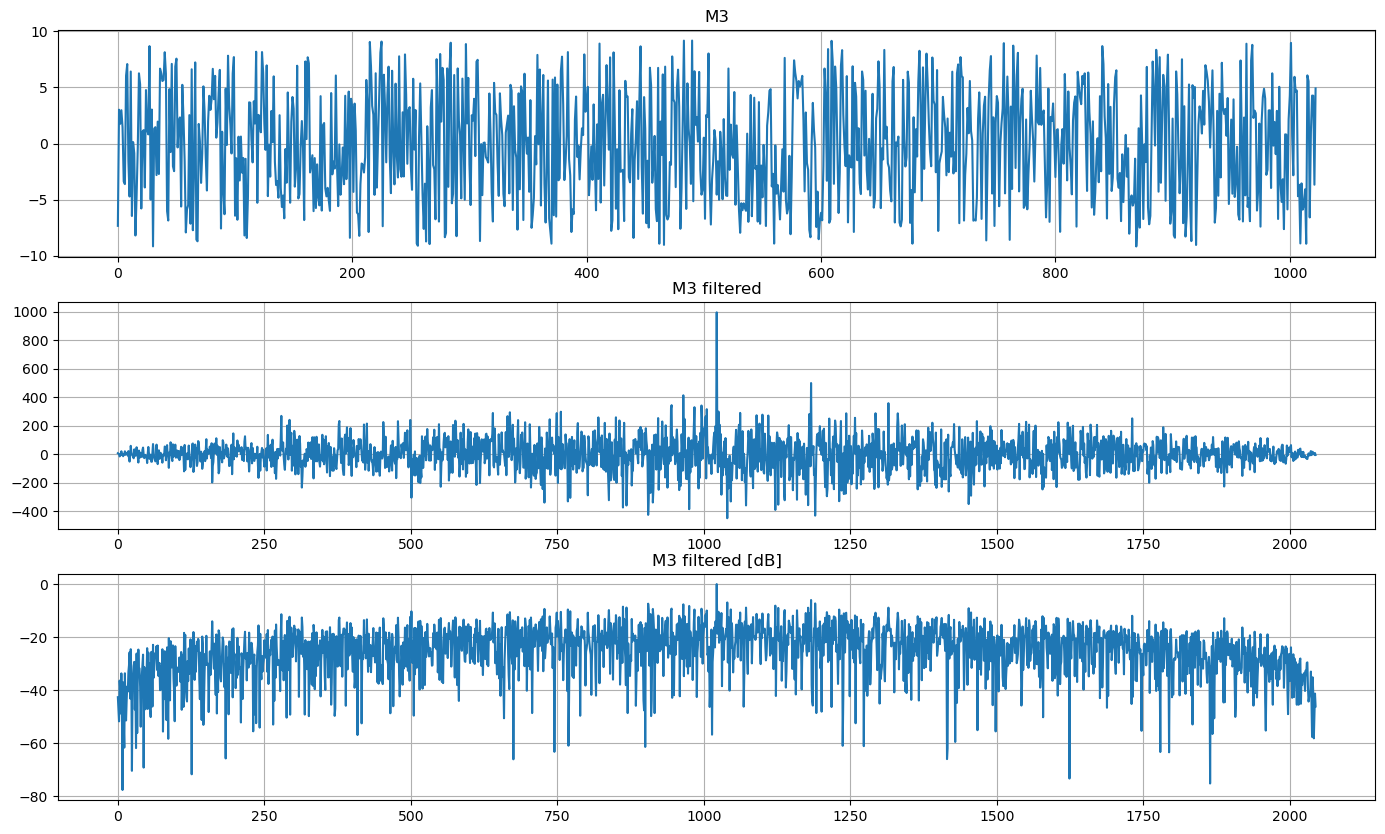

In [17]:
# (7) Сформировать последовательность M3, добавив к M1 шум.

def max_len_seq_noise_and_filter(rng_vect, Anoise):
    M3 = []
    for i in range(len(M1)):
        M3.append(M1[i] + (rng_vect[i]*2-1) * Anoise)
    # Отфильтровать M1 из зашумленного сигнала
    M3_filtered = np.correlate(M3, M1, mode='full')
    for i in range(len(M3_filtered)):
        if np.abs(M3_filtered[i]) <= 0.1: M3_filtered[i] = 0.1
    # Найти 20 логарифмов фильтрованного
    Amax = max(np.abs(M3_filtered.astype(float)))
    M3_db = np.log10(np.abs(M3_filtered.astype(float)) / Amax) * 20
    return M3, M3_filtered, M3_db

Anoise = 15
Anoise_step = Anoise / 2
Epsilon = 0.1
M3, M3_filtered, M3_filtered_db = [], [], []

rng = np.random.default_rng()
rng_vect = rng.random(len(M1))

while True:
    M3, M3_filtered, M3_filtered_db = max_len_seq_noise_and_filter(rng_vect, Anoise)
    sorted_db = sorted(M3_filtered_db)
    if np.abs(sorted_db[-1] - sorted_db[-2] - 6) < Epsilon:
        break
    if sorted_db[-1] - sorted_db[-2] - 6 < 0:
        print(f'Reduce noise {Anoise} >= {Anoise-Anoise_step}')
        Anoise -= Anoise_step
    else:
        print(f'Increase noise {Anoise} >= {Anoise+Anoise_step}')
        Anoise += Anoise_step
    Anoise_step /= 2

print(Anoise)

fig, axes = plt.subplots(3, 1, figsize=(17,10))
axes[0].plot(M3)
axes[0].set_title('M3')
axes[0].grid()
axes[1].plot(M3_filtered)
axes[1].set_title('M3 filtered')
axes[1].grid()
axes[2].plot(M3_filtered_db)
axes[2].set_title('M3 filtered in dB')
axes[2].grid()
fig.show()

C:\Users\8230778\AppData\Local\Temp\ipykernel_10532\3947037796.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


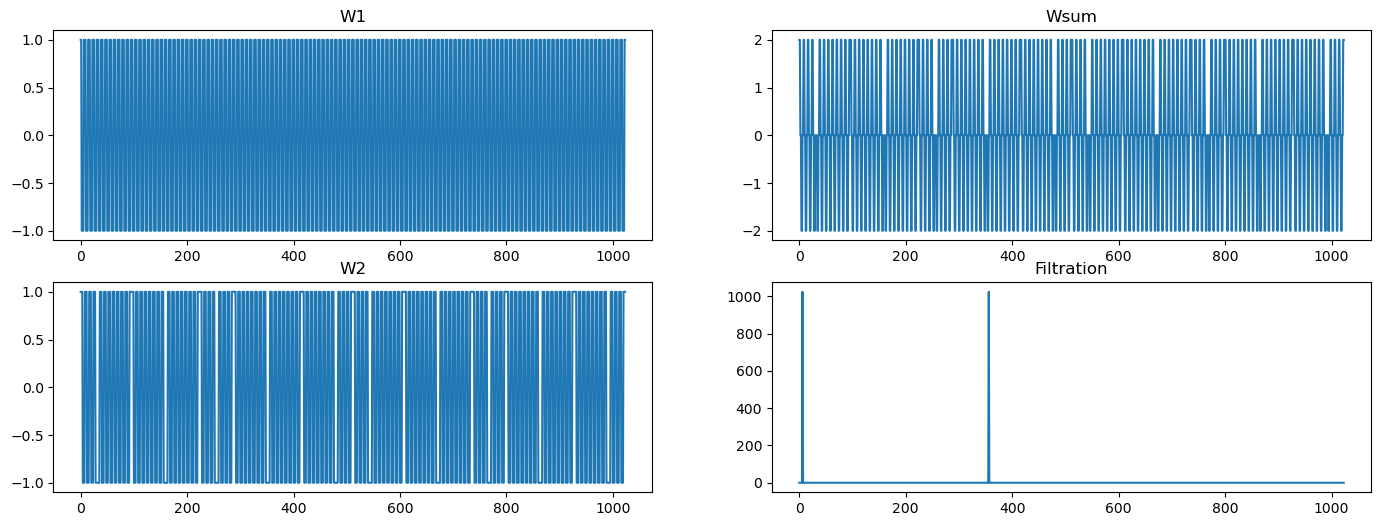

In [18]:
from scipy.linalg import hadamard
from sympy.discrete.transforms import fwht

data1 = 6
data2 = 356
r = 10

H = hadamard(2**r, dtype=float)
W1 = H[data1]
W2 = H[data2]

Wsum = []
for i in range(len(W1)):
    Wsum.append(W1[i] + W2[i])

fig, axes = plt.subplots(2, 2, figsize=(17,6))
axes[0,0].plot(W1)
axes[0,0].set_title('W1')
axes[1,0].plot(W2)
axes[1,0].set_title('W2')
axes[0,1].plot(Wsum)
axes[0,1].set_title('Wsum')
axes[1,1].plot(fwht(Wsum))
axes[1,1].set_title('Filtration')
fig.show()

7.03125


C:\Users\8230778\AppData\Local\Temp\ipykernel_10532\3681182664.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


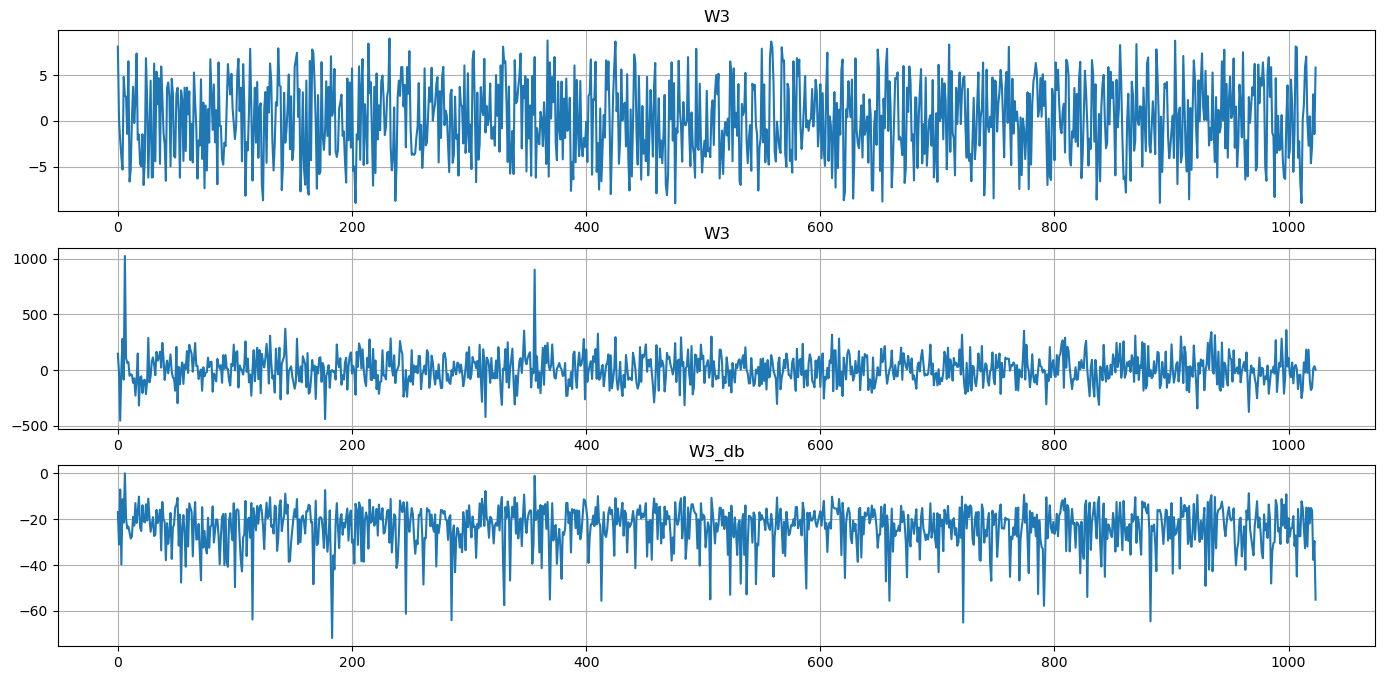

In [19]:
# (7) Сформировать последовательность M3, добавив к M1 шум.

def walsh_seq_noise_and_filter(rng_vect, Anoise):
    W3 = []
    for i in range(len(Wsum)):
        W3.append(Wsum[i] + (rng_vect[i]*2-1) * Anoise)
    # Отфильтровать сигнал
    W3_filtered = np.array(fwht(W3))
    for i in range(len(W3_filtered)):
        if np.abs(W3_filtered[i]) <= 0.1: W3_filtered[i] = 0.1
    # Найти 20 логарифмов фильтрованного
    Amax = max(np.abs(W3_filtered.astype(float)))
    W3_db = np.log10(np.abs(W3_filtered.astype(float)) / Amax) * 20
    return W3, W3_filtered, W3_db

Anoise = 15
Anoise_step = Anoise / 2
Epsilon = 0.1
W3, W3_filtered, W3_filtered_db = [], [], []

rng = np.random.default_rng()
rng_vect = rng.random(len(Wsum))

while True:
    W3, W3_filtered, W3_filtered_db = walsh_seq_noise_and_filter(rng_vect, Anoise)
    sorted_db = sorted(W3_filtered_db)
    if np.abs(sorted_db[-2] - sorted_db[-3] - 6) < Epsilon:
        break
    if sorted_db[-2] - sorted_db[-3] - 6 < 0:
        Anoise -= Anoise_step
    else:
        Anoise += Anoise_step
    Anoise_step /= 2

print(Anoise)

fig, axes = plt.subplots(3, 1, figsize=(17,8))
axes[0].plot(W3)
axes[0].set_title('W3')
axes[0].grid()
axes[1].plot(W3_filtered)
axes[1].set_title('W3 filtered')
axes[1].grid()
axes[2].plot(W3_filtered_db)
axes[2].set_title('W3 filtered in dB')
axes[2].grid()
fig.show()